# Lecture 8: Distributions — Bar Charts, Binning, Histograms
v.ekc

A **distribution** answers: what values does a variable take, and how often? Today: categorical distributions (bar charts) and numerical ones (histograms), plus the Area Principle....

**Today's sections:**
1. Categorical distributions
2. Bar charts
3. Numerical distributions and binning
4. Histograms
5. The vertical axis

In [52]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True

---
## 1. Categorical Distributions

Which studios released the top movies? Let's count, first the hard way, then the one-liner lol

### Try It 1: Count the studios 😊

1. How many movies were released by MGM? Disney? Fox? (Use the moves you know.)

In [60]:
top_movies = Table.read_table('top_movies_2017.csv')
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [3]:
studios = top_movies.select('Studio')
studios

Studio
MGM
Fox
Fox
Universal
Paramount
Paramount
Universal
MGM
Warner Brothers
Disney


In [4]:
num_MGM = ...
num_MGM

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Doctor Zhivago,MGM,111721910,1103564200,1965
Ben-Hur,MGM,74000000,871220000,1959
West Side Story,MGM,43656822,497575800,1961
"It's a Mad, Mad, Mad, Mad World",MGM,46332858,478952400,1963
2001: A Space Odyssey,MGM,56954992,385261600,1968
Rain Man,MGM,172825435,384863200,1988


In [5]:
num_Disney = ...
num_Disney

Title,Studio,Gross,Gross (Adjusted),Year
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937
101 Dalmatians,Disney,144880014,888264400,1961
Fantasia,Disney,76408097,738256500,1941
Mary Poppins,Disney,102272727,695036400,1964
The Jungle Book,Disney,141843612,655014400,1967
Sleeping Beauty,Disney,51600000,646090100,1959
Pinocchio,Disney,84254167,599215600,1940
Cinderella (1950),Disney,93141149,536079700,1950
Lady and the Tramp,Disney,93602326,495483100,1955
Swiss Family Robinson,Disney,40356000,478353100,1960


In [ ]:
num_Fox = ...
num_Fox

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*`where` + `num_rows` works (once per studio). Keep reading for the better way.*

```python
# MGM
num_MGM = studios.where('Studio', 'MGM').num_rows

# Disney
num_Disney = studios.where('Studio', 'Disney').num_rows

# Fox
num_Fox = studios.where('Studio', 'Fox').num_rows
```

</details>

Let's explore another way to do this.

> **`group` counts every category at once**, one line instead of one `where` per studio. This method is about to become your best friend.

In [6]:
studio_distribution = studios.group('Studio')
studio_distribution

Studio,count
AVCO,1
Buena Vista,35
Columbia,9
Disney,11
Dreamworks,3
Fox,24
IFC,1
Lionsgate,3
MGM,7
Metro,1


In [7]:
sum(studio_distribution.column('count'))

200

---
## 2. Bar Charts

A categorical distribution's natural picture. Sorting first makes it readable. (Why no pie charts?...because comparing angles is hard; comparing lengths is easy! 🥧🚫)

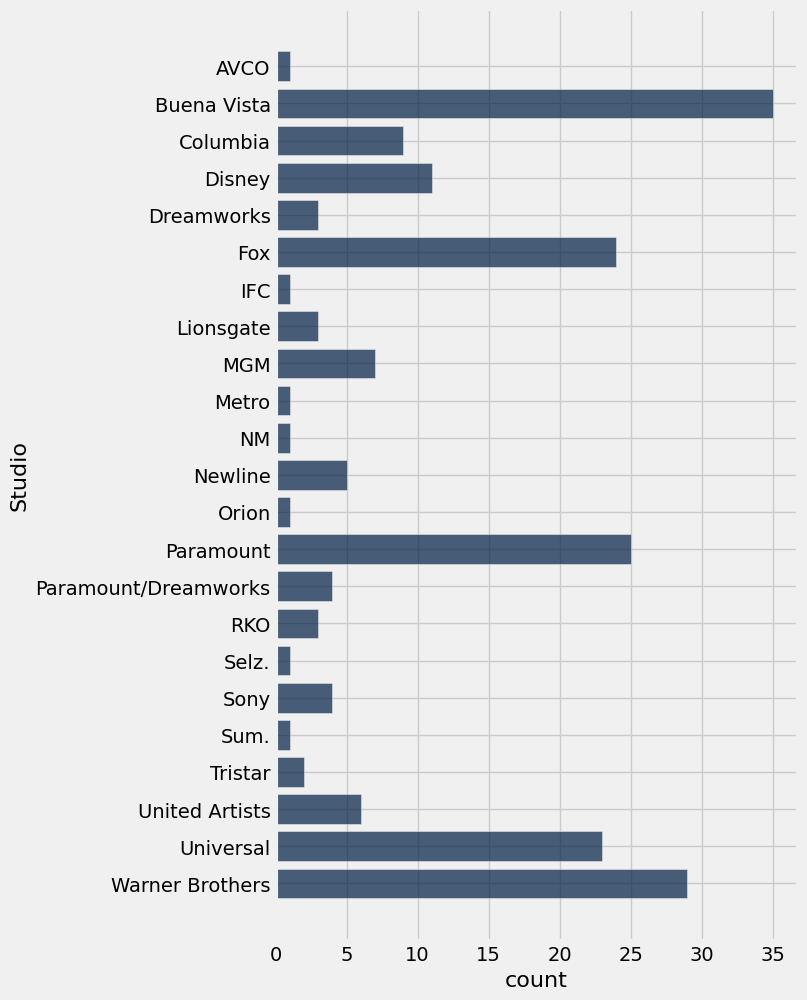

In [48]:
# tablename.barh.(col_with_categories, col_with_values)

studio_distribution.barh('Studio', 'count')

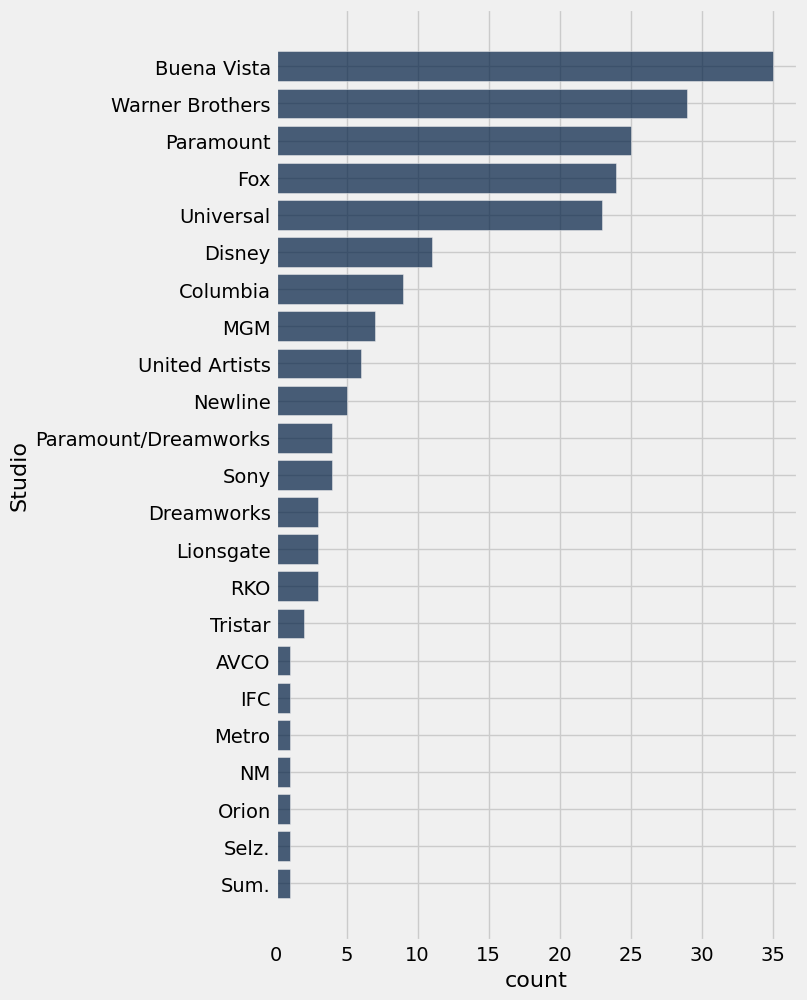

In [9]:
studio_distribution.sort('count', descending=True).barh('Studio')

### Try It 2: Top studio 😊

1. Which studio released the most top-200 movies, and how many? Answer with code.

2. What *fraction* of all 200 movies does that one studio account for?

In [13]:
# 1. top studio and its count



('Buena Vista', 35)

In [18]:
# 2. fraction of all movies


0.17499999999999999

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The grouped table is just a table, sort it and pull items out.*

```python
# 1.
top = studio_distribution.sort('count', descending=True)
top.column('Studio').item(0), top.column('count').item(0)

# 2.
top.column('count').item(0) / top_movies.num_rows
```

</details>

---
## 3. Numerical Distributions and Binning

Numbers need a different move: chop the number line into **bins**, then count how many values land in each.

### 📋 Reference Table

| Code | What it does |
|---|---|
| `t.group('col')` | count occurrences of each category |
| `t.bin('col', bins=arr)` | count values landing in each bin |
| `t.hist('col', unit='Year')` | histogram, auto bins |
| `t.hist('col', bins=arr, unit='Year')` | histogram with your bins |
| `[a, b)` | bins include the left edge, not the right |

In [61]:
ages = 2026 - top_movies.column('Year')
top_movies = top_movies.with_column('Age', ages)
top_movies

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,198676459,1796176700,1939,87
Star Wars,Fox,460998007,1583483200,1977,49
The Sound of Music,Fox,158671368,1266072700,1965,61
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,44
Titanic,Paramount,658672302,1204368000,1997,29
The Ten Commandments,Paramount,65500000,1164590000,1956,70
Jaws,Universal,260000000,1138620700,1975,51
Doctor Zhivago,MGM,111721910,1103564200,1965,61
The Exorcist,Warner Brothers,232906145,983226600,1973,53
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,89


In [63]:
# just make it look more readable!
#   new method: table.set_format(colname, CurrencyFormatter

top_movies = top_movies.with_column('Age', ages).set_format(['Gross', 'Gross (Adjusted)'], CurrencyFormatter)
top_movies.show(5)

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,"$198,676,459","$1,796,176,700",1939,87
Star Wars,Fox,"$460,998,007","$1,583,483,200",1977,49
The Sound of Music,Fox,"$158,671,368","$1,266,072,700",1965,61
E.T.: The Extra-Terrestrial,Universal,"$435,110,554","$1,261,085,000",1982,44
Titanic,Paramount,"$658,672,302","$1,204,368,000",1997,29


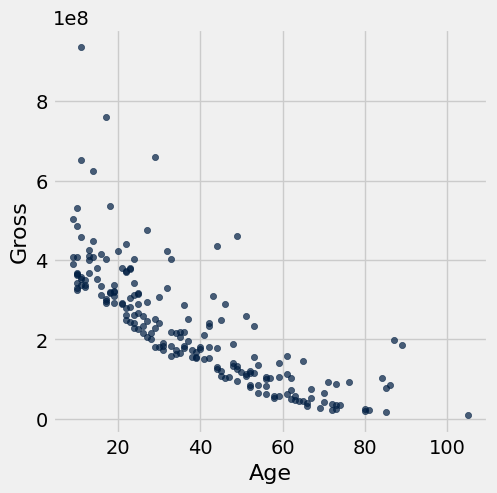

In [67]:
# quickie viz!

top_movies.scatter(5, 2)

How many movies are we binning, and how old do they run?

In [20]:
top_movies.num_rows

200

In [21]:
min(ages), max(ages)

(7, 103)

Equal 10-year bins first, the counts must add back up to 200:

In [22]:
equal_bins = top_movies.bin('Age', bins = np.arange(0, 111, 10))

# or
# equal_bins = top_movies.bin('Age', bins = np.arange(0, max(ages)+10, 10))

equal_bins.show()

bin,Age count
0,18
10,32
20,41
30,27
40,26
50,23
60,16
70,10
80,6
90,0


In [23]:
sum(equal_bins.column('Age count'))

200

Bins don't have to be equal; here's a deliberately lumpy set:

In [30]:
my_bins = make_array(0, 10, 20, 25, 40, 57, 60, 103)

In [31]:
binned_data = top_movies.bin('Age', bins = my_bins)
binned_data

bin,Age count
0,18
10,32
20,25
25,43
40,43
57,6
60,33
103,0


In [32]:
sum(binned_data.column('Age count'))

200

---
## 4. Histograms

A histogram is binning, drawn. But careful, with **unequal bins**, taller doesn't mean more. The **Area Principle**: the *area* of each bar shows the percent of data in that bin.

In [44]:
top_movies.show(3)

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,198676459,1796176700,1939,85
Star Wars,Fox,460998007,1583483200,1977,47
The Sound of Music,Fox,158671368,1266072700,1965,59


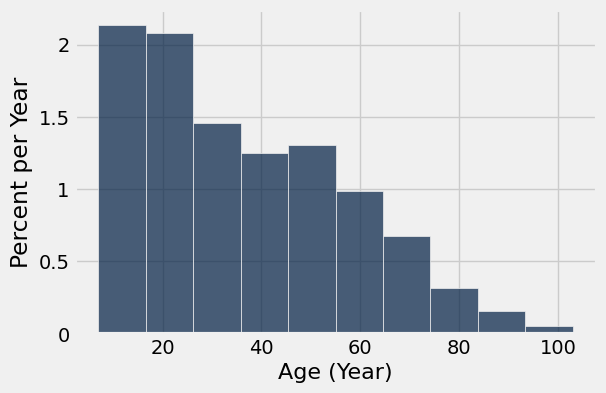

In [42]:
# Let's explore the hist function!

### QUESTION: does .hist() default to 10 bins???
#             y-label: is it auto "Percent per"+colname?


top_movies.hist('Age', unit='Year')

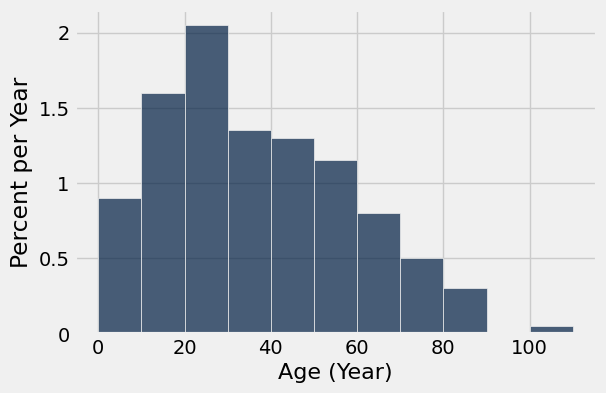

In [41]:
# Let's try equally spaced bins
#  we supply the bins

top_movies.hist('Age', bins = np.arange(0, 111, 10), unit = 'Year')

Read a bar with the Area Principle: height × width = percent. The `[10, 20)` bar:

In [68]:
# percent of individuals in that bin is the width of bin * height of bin

0.016 * (20 - 10)

0.16

In [46]:
equal_bins

bin,Age count
0,18
10,32
20,41
30,27
40,26
50,23
60,16
70,10
80,6
90,0


In [69]:
# check the percent?

total_count = sum(equal_bins.column('Age count'))
32/total_count

0.16

> **Height = density, area = percent.** The `[10, 20)` bar has height ≈ 1.6 percent-per-year × width 10 years = 16% of the movies. Read histogram heights as *crowding*, not counts.

### Try It 4: Bin widths, your call 😊

1. Draw the Age histogram with **20-year-wide** bins from 0 to 120.

2. Using `equal_bins`, what **percent** of the movies have an age in `[30, 40)`?

3. On your 20-year histogram, roughly what height should the `[20, 40)` bar have? (Percent ÷ width!)

In [ ]:
# 1. 20-year bins


In [ ]:
# 2. percent in [30, 40)


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Wider bins, same rule: area is percent, so height is percent ÷ width.*

```python
# 1.
top_movies.hist('Age', bins=np.arange(0, 121, 20), unit='Year')

# 2.
equal_bins.where('bin', 30).column('Age count').item(0) / 200 * 100
```

*3. Add the `[20,30)` and `[30,40)` percents, divide by the 20-year width: that's the bar's height in percent-per-year.*

</details>

---
## 5. The Vertical Axis

What happens if we plot raw counts on unequal bins instead? (`normed=False`; spoiler: don't!)

In [ ]:
my_bins

In [ ]:
binned_data

Add a percent column, then draw the *dishonest* count-scale version:

In [ ]:
# Add a column containing what percent of movies are in each bin
binned_data = binned_data.with_column(
    'Percent', 100*binned_data.column('Age count')/200)
binned_data

In [ ]:
# Let's make this histogram
top_movies.hist('Age', bins = my_bins, unit = 'Year', normed = False)

### Try It 5: Density detective 😊

1. Using `binned_data`'s `Percent` column, compute the **density** (percent per year) of the wide `[40, 57)` bin.

2. Is `[40, 57)` actually more crowded than `[57, 60)`? Compute that density too and compare.

In [ ]:
# 1. density of [40, 57)


In [ ]:
# 2. density of [57, 60)


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Divide each bin's percent by its width, the normal, equal-binned histogram does this for you.*

```python
# 1.
binned_data.where('bin', 40).column('Percent').item(0) / (57 - 40)

# 2.
binned_data.where('bin', 57).column('Percent').item(0) / (60 - 57)
```

</details>

> **Compare this to the version above:** the wide `[40, 57)` bin *looks* huge on a count scale simply because it's wide. The Area Principle exists to stop exactly this lie. 😬

---
> **Today's takeaway:** `group` + bar chart for categories; `bin`/`hist` for numbers; and on histograms, area, not height, tells you how much data is where. Homework 3's histogram section tests this idea directly.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — distribution of a column
```python
t.group('category').sort('count', descending=True).barh('category')
t.hist('number', bins=np.arange(start, stop, width), unit='...')
```